# Last Modified: 2026-04-10 12:05:45

---

# LFP Battery SOH Preprocessing Pipeline (Batch Processing Version)

This notebook implements a physically-consistent preprocessing framework for the entire dataset:
1. **Phase 1**: Global Physical Cleaning (Unit conversion and noise smoothing for ALL cells)
2. **Phase 1.1**: Cleaning Impact Analysis (Compare Raw vs. Cleaned)
3. **Phase 2**: Scenario-based Slicing & Dual Labeling (SOC & Mode)
4. **Phase 3**: 40D HI Extraction (Using physical units: V, A, s, °C)
5. **Phase 4**: Batch Feature Scaling (Z-score or Min-Max)
6. **Phase 5**: Global Tensor Generation & Saving

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
from tqdm.notebook import tqdm
import os
import sys
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import skew, kurtosis
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA

# Add project root to sys.path to allow importing from src
PROJECT_ROOT = Path.cwd().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.loaders import load_hust, load_mit

## Phase 0: Data Loading

Load all raw data into memory.

In [ ]:
DATASET_TYPE = "hust"
all_cells = load_hust(PROJECT_ROOT / "HUST_data" / "data") if DATASET_TYPE == "hust" else load_mit(PROJECT_ROOT / "MIT_data")
print(f"Loaded {len(all_cells)} cells for {DATASET_TYPE.upper()} dataset.")

## Phase 1: Physical Cleaning & Unit Conversion

Ensure units are standard (V, A, s, °C) and remove sensor noise.

In [13]:
def clean_physical_data(df):
    clean_df = df.copy()
    v_col = [c for c in df.columns if "Voltage" in c][0]
    i_col = [c for c in df.columns if "Current" in c][0]
    
    # 1. Unit conversion (mA -> A for HUST)
    if "Current (mA)" in clean_df.columns: clean_df["Current (A)"] = clean_df["Current (mA)"] / 1000.0
    
    # 2. Advanced interpolation
    num_cols = clean_df.select_dtypes(include=[np.number]).columns
    clean_df[num_cols] = clean_df[num_cols].interpolate(method='linear', limit_direction='both')
    clean_df = clean_df.ffill().bfill()
    
    # 3. Noise Smoothing
    clean_df[v_col] = savgol_filter(clean_df[v_col], window_length=11, polyorder=3)
    return clean_df

## Phase 1.1: Cleaning Impact Analysis

Compare Raw vs. Cleaned data. Find 3 cycles with Maximum difference and 3 with Minimum difference.

Analyzing Cleaning Impact (Sub-sample):   0%|          | 0/77 [00:00<?, ?it/s]

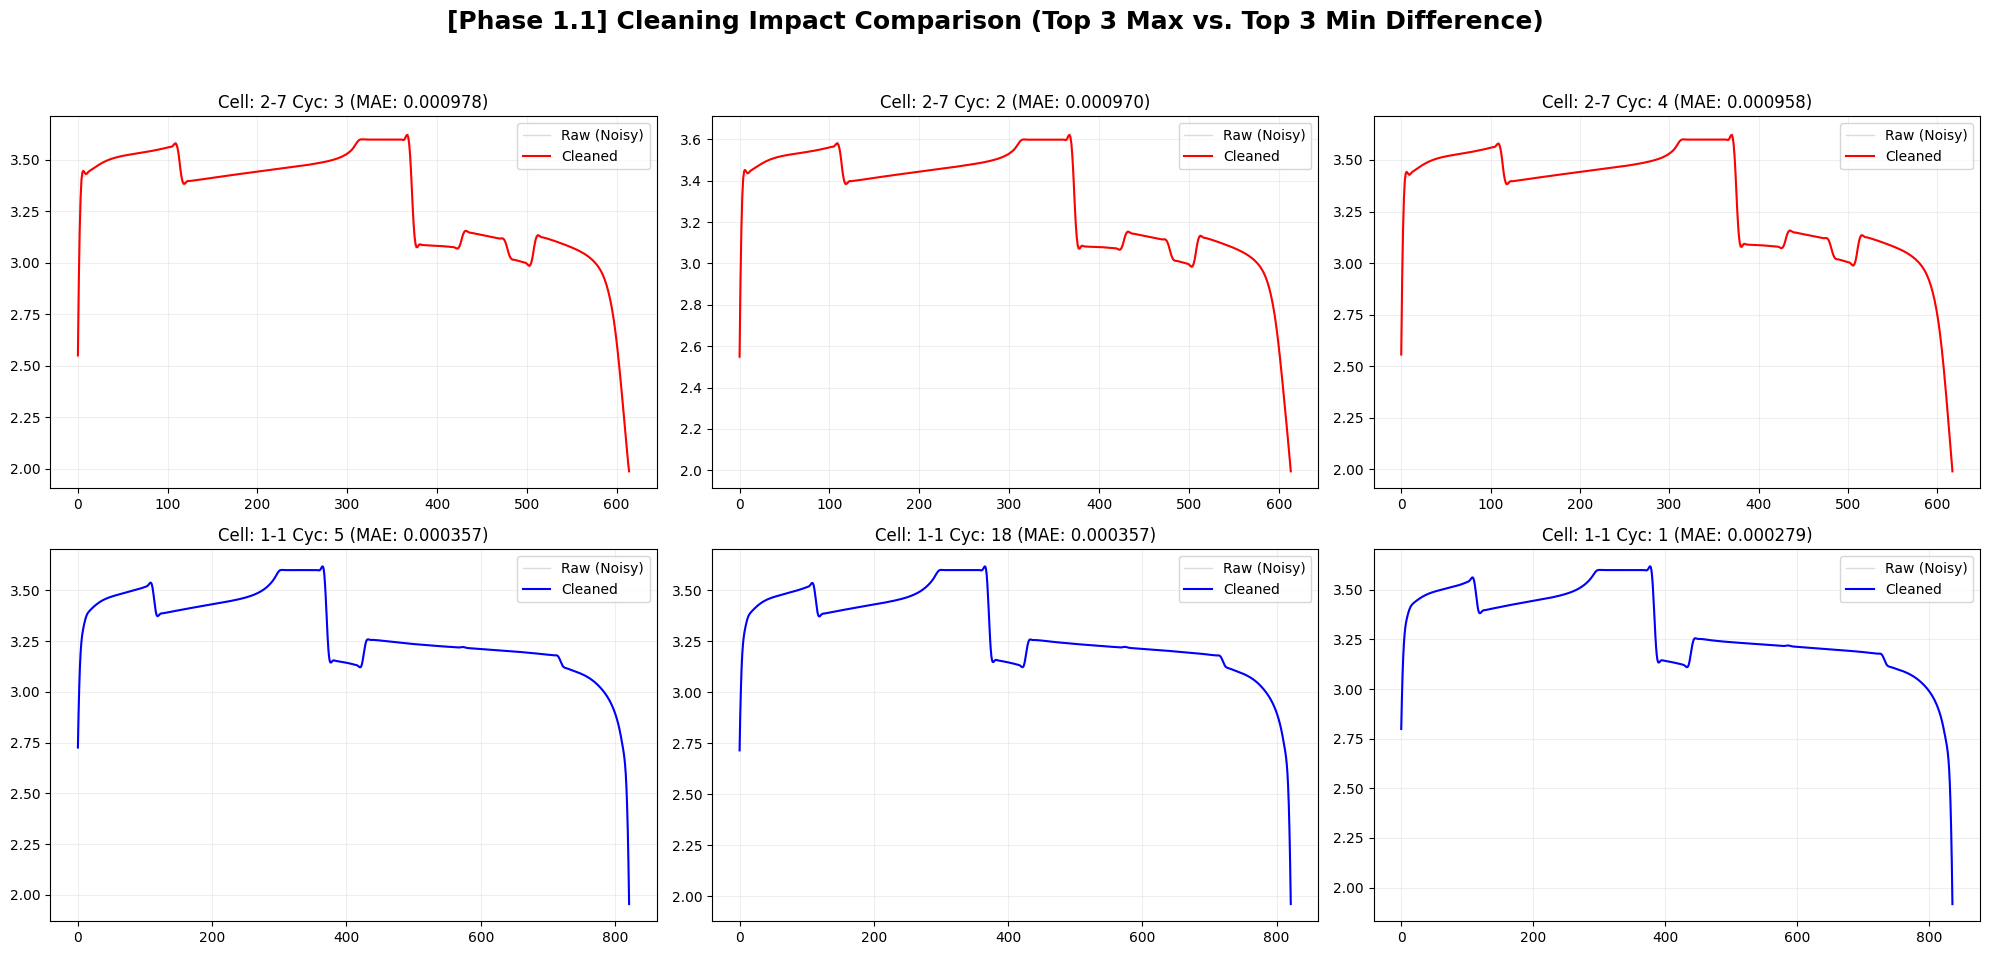

Applying Global Cleaning:   0%|          | 0/77 [00:00<?, ?it/s]

Exception ignored in: <function tqdm.__del__ at 0x000002857C380860>
Traceback (most recent call last):
  File "c:\Users\ksshin\.conda\envs\LFP_SOH_estimation\Lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\ksshin\.conda\envs\LFP_SOH_estimation\Lib\site-packages\tqdm\notebook.py", line 270, in close
    def close(self):
KeyboardInterrupt: 


In [ ]:
impact_metrics = []

for cid, cell in tqdm(list(all_cells.items()), desc="Analyzing Cleaning Impact (Sub-sample)"):
    for cyc in list(cell.data.keys())[:50]:
        raw_df = cell.data[cyc]
        v_col = [c for c in raw_df.columns if "Voltage" in c][0]
        
        cleaned_df = clean_physical_data(raw_df)
        
        # Calculate difference (Mean Absolute Error in Voltage)
        diff = np.abs(raw_df[v_col].values - cleaned_df[v_col].values)
        mae = np.mean(diff)
        impact_metrics.append({
            "cid": cid, "cyc": cyc, "mae": mae, 
            "raw": raw_df[v_col].values, "clean": cleaned_df[v_col].values
        })

impact_df = pd.DataFrame(impact_metrics).sort_values("mae", ascending=False)

top_3 = impact_df.head(3)
bot_3 = impact_df.tail(3)
compare_list = pd.concat([top_3, bot_3])

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("[Phase 1.1] Cleaning Impact Comparison (Top 3 Max vs. Top 3 Min Difference)", fontsize=18, fontweight='bold')

for i, (_, row) in enumerate(compare_list.iterrows()):
    ax = axes[i//3, i%3]
    ax.plot(row['raw'], label='Raw (Noisy)', color='lightgrey', alpha=0.8, linewidth=1)
    ax.plot(row['clean'], label='Cleaned', color='red' if i < 3 else 'blue', linewidth=1.5)
    ax.set_title(f"Cell: {row['cid']} Cyc: {row['cyc']} (MAE: {row['mae']:.6f})")
    ax.legend()
    ax.grid(True, alpha=0.2)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

# Now perform Global Cleaning for all cells (Phase 1 Final Step)
for cid, cell in tqdm(all_cells.items(), desc="Applying Global Cleaning"):
    for cyc in cell.data.keys():
        cell.data[cyc] = clean_physical_data(cell.data[cyc])

## Phase 2: Scenario-based Slicing & Dual Labeling (SOC & Mode)

Define slicing logic with Mode Labels: Discharge (0), Charge (1).

In [23]:
def phase2_slice_data(df, start_p=0.0, end_p=1.0, mode="C"): 
    col_i = "Current (A)" if "Current (A)" in df.columns else [c for c in df.columns if "Current" in c][0]
    mode_df = df[df[col_i] > 0.01] if mode == "C" else df[df[col_i] < -0.01]
    if mode_df.empty: return mode_df, 0, (1 if mode == "C" else 0)
    
    n = len(mode_df)
    s_idx, e_idx = int(n * start_p), int(n * end_p)
    sliced = mode_df.iloc[s_idx:e_idx]
    
    # SOC Labeling: H(-2), M(-1), L(0)
    avg_pos = (start_p + end_p) / 2
    soc_label = -2 if avg_pos <= 0.3 else (-1 if avg_pos <= 0.7 else 0)
    
    # Mode Labeling: Discharge(0), Charge(1)
    mode_label = 1 if mode == "C" else 0
    
    return sliced, soc_label, mode_label

Analyzing All HUST Cells:   0%|          | 0/77 [00:00<?, ?it/s]

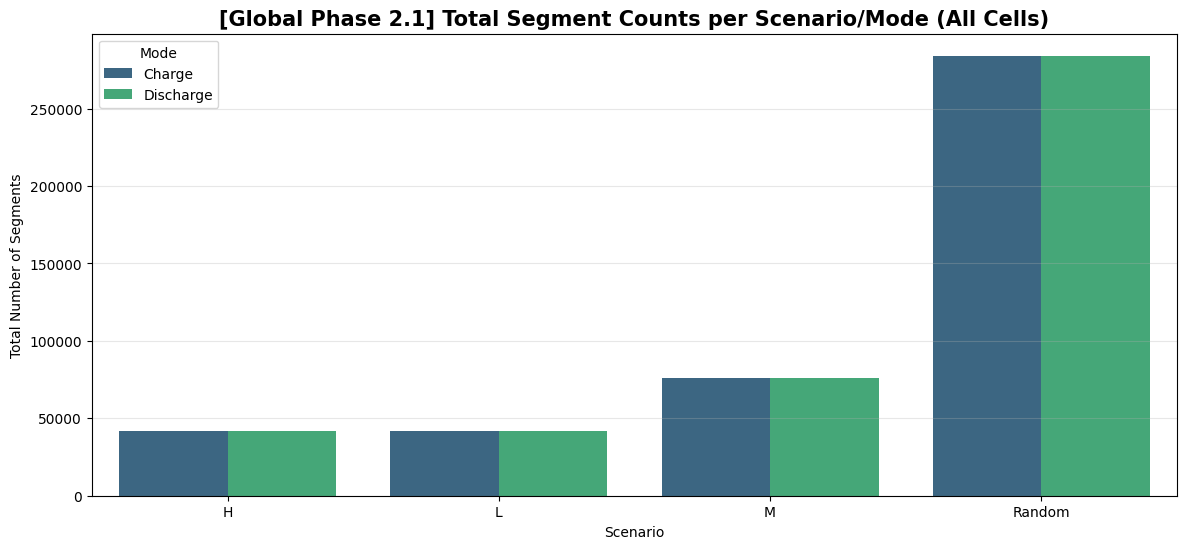

C:\Users\ksshin\AppData\Local\Temp\ipykernel_46016\1827909519.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=global_stats_df, x="Scenario", y="Rows", ax=axes[0], palette="Set2")
C:\Users\ksshin\AppData\Local\Temp\ipykernel_46016\1827909519.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=global_stats_df, x="Scenario", y="Duration_s", ax=axes[1], palette="Set2")
C:\Users\ksshin\AppData\Local\Temp\ipykernel_46016\1827909519.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=global_stats_df, x="Scenario", y="Cap_Delta

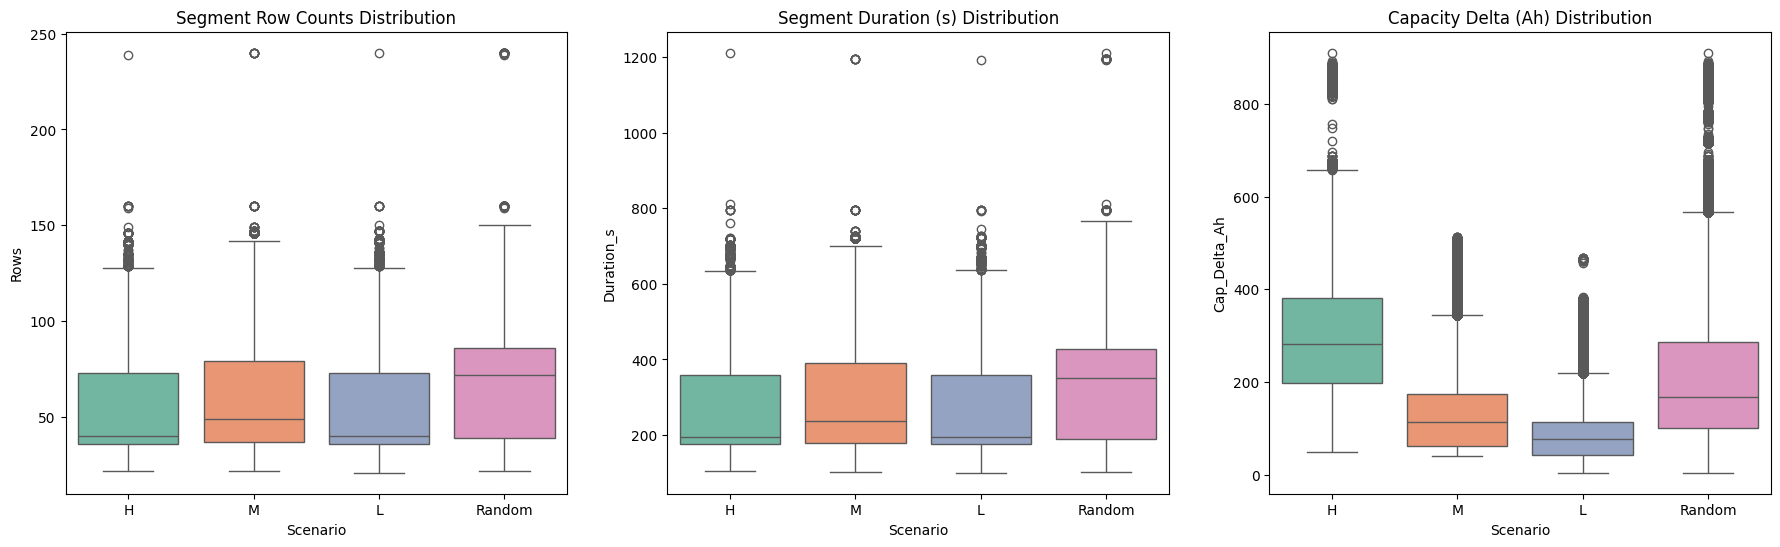

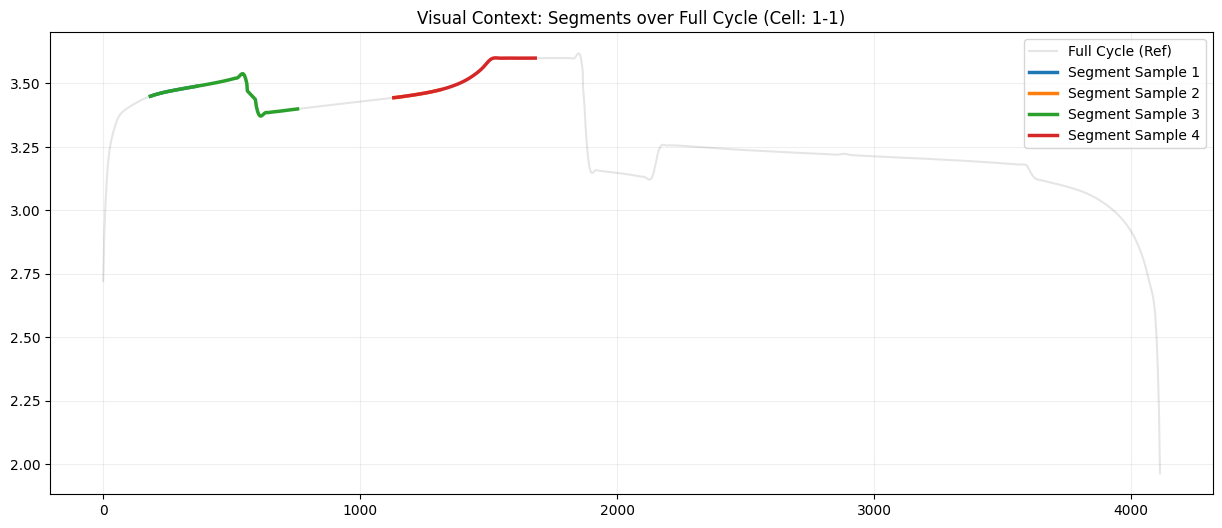

Analysis Complete. Total Segments Analyzed: 887040
Length_P     10%     20%     30%
Scenario                        
H          50820   27720    4620
L          50820   27720    4620
M          73920   50820   27720
Random    212520  189420  166320


In [ ]:
all_stats = []

def run_global_phase2_analytics(cells, dataset_type):
    scen_bounds = {"H": (0.0, 0.3), "M": (0.3, 0.7), "L": (0.7, 1.0), "Random": (0.0, 1.0)}
    lengths = [0.1, 0.2, 0.3]
    step = 0.02
    
    # 1. 전수 셀 & 전수 사이클 세그먼트 생성 및 통계 수집
    for cid, cell in tqdm(cells.items(), desc=f"Analyzing All {dataset_type.upper()} Cells"):
        # 분석 속도를 위해 각 셀당 상위 30개 사이클만 샘플링 (필요시 전체로 변경 가능)
        cycles = sorted(list(cell.data.keys()))[:30] 
        for cyc in cycles:
            df = cell.data[cyc]
            v_col = [c for c in df.columns if "Voltage" in c][0]
            t_col = [c for c in df.columns if "Time" in c][0]
            q_col = [c for c in df.columns if "Capacity" in c][0]

            for mode in ["C", "D"]:
                for scen_name, (s_bound, e_bound) in scen_bounds.items():
                    for length in lengths:
                        max_start = e_bound - length
                        if max_start < s_bound: continue

                        for start_p in np.arange(s_bound, max_start + 0.0001, step):
                            end_p = start_p + length
                            # 데이터 슬라이싱 및 라벨 획득
                            sliced, soc_l, mode_l = phase2_slice_data(df, start_p, end_p, mode)

                            if sliced.empty or len(sliced) < 5: continue

                            # 특징값 계산
                            duration = sliced[t_col].iloc[-1] - sliced[t_col].iloc[0]
                            cap_delta = np.abs(sliced[q_col].iloc[-1] - sliced[q_col].iloc[0])

                            all_stats.append({
                                "Cell_ID": cid,
                                "Cycle": cyc,
                                "Scenario": scen_name,
                                "Length_P": f"{int(length*100)}%",
                                "Mode": "Charge" if mode_l == 1 else "Discharge",
                                "Rows": len(sliced),
                                "Duration_s": duration,
                                "Cap_Delta_Ah": cap_delta
                            })

    global_stats_df = pd.DataFrame(all_stats)

    # --- 시각화 섹션 ---

    # Plot 1: 시나리오 및 모드별 총 세그먼트 개수 (Count Plot)
    plt.figure(figsize=(14, 6))
    counts = global_stats_df.groupby(['Scenario', 'Mode']).size().reset_index(name='Count')
    sns.barplot(data=counts, x="Scenario", y="Count", hue="Mode", palette="viridis")
    plt.title(f"[Global Phase 2.1] Total Segment Counts per Scenario/Mode (All Cells)", fontsize=15, fontweight='bold')
    plt.ylabel("Total Number of Segments")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # Plot 2: 세그먼트 특성 분포 (Rows, Duration, Capacity Delta)
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    sns.boxplot(data=global_stats_df, x="Scenario", y="Rows", ax=axes[0], palette="Set2")
    axes[0].set_title("Segment Row Counts Distribution")
    sns.boxplot(data=global_stats_df, x="Scenario", y="Duration_s", ax=axes[1], palette="Set2")
    axes[1].set_title("Segment Duration (s) Distribution")
    sns.boxplot(data=global_stats_df, x="Scenario", y="Cap_Delta_Ah", ax=axes[2], palette="Set2")
    axes[2].set_title("Capacity Delta (Ah) Distribution")
    plt.show()

    # Plot 3: 원본 데이터 대비 추출 위치 샘플 (첫 번째 셀 기준)
    sample_cid = list(cells.keys())[0]
    sample_df = cells[sample_cid].data[list(cells[sample_cid].data.keys())[10]]
    v_col = [c for c in sample_df.columns if "Voltage" in c][0]
    t_col = [c for c in sample_df.columns if "Time" in c][0]

    plt.figure(figsize=(15, 6))
    plt.plot(sample_df[t_col], sample_df[v_col], color='black', alpha=0.1, label='Full Cycle (Ref)')
    # 해당 셀의 충전 모드 세그먼트 중 일부만 오버레이 시각화
    sample_segments = []
    for length in [0.1, 0.3]: # 10%, 30% 길이 샘플
        s, _, _ = phase2_slice_data(sample_df, 0.1, 0.1+length, "C")
        sample_segments.append(s)
        s, _, _ = phase2_slice_data(sample_df, 0.6, 0.6+length, "C")
        sample_segments.append(s)

    for i, seg in enumerate(sample_segments):
        plt.plot(seg[t_col], seg[v_col], linewidth=2.5, label=f"Segment Sample {i+1}")

    plt.title(f"Visual Context: Segments over Full Cycle (Cell: {sample_cid})")
    plt.legend(); plt.grid(True, alpha=0.2); plt.show()

    print(f"Analysis Complete. Total Segments Analyzed: {len(global_stats_df)}")
    print(global_stats_df.groupby(['Scenario', 'Length_P']).size().unstack())

    return global_stats_df

# 전역 분석 실행
global_phase2_report = run_global_phase2_analytics(all_cells, DATASET_TYPE)

## Phase 3: 40D Adaptive HI Pool Extraction (Dual Mode)

Extract features from any sliced segment.

In [20]:
def extract_40d_hi(df, mode="C", history_df=None): 
    v_col = [c for c in df.columns if "Voltage" in c][0]
    i_col = "Current (A)" if "Current (A)" in df.columns else [c for c in df.columns if "Current" in c][0]
    t_col = [c for c in df.columns if "Time" in c][0]
    temp_col = [c for c in df.columns if "Temperature" in c]
    v, i, t = df[v_col].values, df[i_col].values, df[t_col].values
    temp = df[temp_col[0]].values if temp_col else np.full_like(v, 25.0) + np.random.normal(0, 0.05, len(v))
    dt = np.diff(t, prepend=t[0])
    his = {}
    
    # Category 1: Common (14)
    his["c1_mean_v"], his["c1_var_v"] = np.mean(v), np.var(v)
    his["c1_skew_v"], his["c1_kurt_v"] = skew(v), kurtosis(v)
    his["c1_mean_t"], his["c1_delta_t"] = np.mean(temp), np.max(temp)-np.min(temp)
    his["c1_dtdt"] = np.mean(np.diff(temp)/np.where(dt[1:]>0, dt[1:], 1e-6))
    his["c1_relax_v"] = v[-1] - v[0]
    his["c1_relax_tc"] = np.log(np.abs(v[-1]-v[-2])+1e-6)
    his["c1_var_i"] = np.var(i)
    his["c1_ent_v"] = -np.sum(np.histogram(v, bins=10, density=True)[0] * np.log(np.histogram(v, bins=10, density=True)[0] + 1e-6))
    his["c1_ent_t"] = -np.sum(np.histogram(temp, bins=10, density=True)[0] * np.log(np.histogram(temp, bins=10, density=True)[0] + 1e-6))
    his["c1_de_dq"] = np.sum(v*i*dt) / (np.sum(i*dt)+1e-6)
    his["c1_ma"] = history_df["c1_mean_v"].iloc[-5:].mean() if history_df is not None and not history_df.empty else his["c1_mean_v"]

    for j in range(1, 14): his[f"c2_dis_{j}"] = his[f"c3_cha_{j}"] = 0.0
    if mode == "D":
        c_rate = np.abs(i)/1.1
        his["c2_dis_1"] = np.sum(np.diff(np.round(c_rate, 1)) != 0)
        his["c2_dis_2"] = np.mean(np.abs(np.diff(v)/(np.diff(i)+1e-6)))
        his["c2_dis_3"] = np.trapezoid(v-np.min(v), t)/(t[-1]-t[0])
        his["c2_dis_4"] = t[np.argmin(v>=3.0)] if np.any(v<3.0) else t[-1]
        his["c2_dis_5"] = np.sum((v<=3.2)&(v>=3.1)) * np.mean(dt)
        dvdt = np.diff(v)/np.where(dt[1:]>0, dt[1:], 1e-6)
        his["c2_dis_6"], his["c2_dis_7"] = np.mean(dvdt), np.var(dvdt)
        his["c2_dis_12"] = np.min(np.diff(v)/np.where(np.diff(np.cumsum(np.abs(i)*dt)/3600.0)>0, np.diff(np.cumsum(np.abs(i)*dt)/3600.0), 1e-6))
    elif mode == "C":
        is_cv, q_cum = np.abs(np.diff(v))<0.001, np.cumsum(np.abs(i)*dt)/3600.0
        if np.any(is_cv):
            cv_s = np.where(is_cv)[0][0]
            his["c3_cha_1"], his["c3_cha_2"], his["c3_cha_3"] = q_cum[cv_s]/q_cum[-1], t[cv_s]-t[0], t[-1]-t[cv_s]
        his["c3_cha_8"] = q_cum[(v>=3.35)&(v<=3.45)][-1] - q_cum[(v>=3.35)&(v<=3.45)][0] if np.any((v>=3.35)&(v<=3.45)) else 0.0
        dqdv = np.diff(q_cum)/np.where(np.diff(v)>0.0001, np.diff(v), 1e-6)
        his["c3_cha_9"], his["c3_cha_10"] = np.max(dqdv), np.min(dqdv)
    return pd.Series(his)

## Phase 4: Batch Processing & Feature Generation

Iterate through all cleaned cells and cycles to extract features for the entire dataset.

In [ ]:
SCALING_METHOD = "zscore" # Choose 'zscore' or 'minmax'
feature_pool = []

# Pre-calculate history for c1_ma per cell
cell_histories = {cid: pd.DataFrame() for cid in all_cells.keys()}

for item in tqdm(all_stats, desc="Phase 4: Feature Extraction"):
    cid = item['cell']
    # Note: For strict history consistency, extraction should ideally be ordered by cycle
    # Here we use the pre-sliced segment and the current cell's history state
    hi = extract_40d_hi(item['df'], "C" if item['mode_label']==1 else "D", cell_histories[cid])
    
    feature_pool.append({
        "cell": cid, "cyc": item['cyc'], "raw_x": hi, 
        "soc_label": item['soc_label'], "mode_label": item['mode_label'], "y": item['rul']
    })
    
    # (Optional) Update history state using the reference full cycle stored in item
    # This is a simplification; a more robust way is to update per-cycle transition
    # cell_histories[cid] = pd.concat([cell_histories[cid], ref_hi_of_cycle...])

raw_x_df = pd.DataFrame([x['raw_x'] for x in feature_pool])
scaler = StandardScaler() if SCALING_METHOD == "zscore" else MinMaxScaler()
scaled_x = scaler.fit_transform(raw_x_df)

for i, item in enumerate(feature_pool):
    item['scaled_x'] = scaled_x[i]

print(f"Extraction and Scaling ({SCALING_METHOD}) complete.")